# Предсказание октановых чисел (RON/MON) методами машинного обучения

## Содержание

1. **Введение** -- RON, MON и их значение в нефтехимии
2. **Загрузка и разведочный анализ данных (EDA)**
3. **Построение молекулярных дескрипторов с RDKit**
4. **Отбор признаков (Feature Selection)**
5. **Обучение моделей** -- базовые модели и CatBoost
6. **Логирование экспериментов с MLflow**
7. **Конфигурация пайплайна с Hydra**
8. **Подбор гиперпараметров с Optuna**
9. **Итоговый пайплайн и выводы**

## 1. Введение

**RON** (Research Octane Number) и **MON** (Motor Octane Number) -- ключевые характеристики топлива, определяющие его детонационную стойкость.

- **RON** измеряется при стандартных условиях (600 об/мин)
- **MON** измеряется при более жестких условиях (900 об/мин, предварительный подогрев)
- **OS** (Octane Sensitivity) = RON - MON

Задача: по структуре молекулы (SMILES) предсказать RON и MON, используя молекулярные дескрипторы.

## 2. Загрузка и разведочный анализ данных (EDA)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

df = pd.read_csv("data.csv", encoding="utf-8-sig")
print(f"Dataset: {df.shape[0]} compounds, {df.shape[1]} columns")
df.head(10)

Dataset: 260 compounds, 26 columns


,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2
5,n-Heptane,Alkanes,CCCCCCCC,2,5,0,0,0,0,0,...,0.0,0,0,0,0,0,0,0.0,0.0,0.0
6,2-Methylpropane,Alkanes,CC(C)C,3,0,1,0,0,0,0,...,1.0,0,0,0,0,0,0,102.1,97.6,4.5
7,2-Methylbutane,Alkanes,CCC(C)C,3,1,1,0,0,0,0,...,1.0,0,0,0,0,0,0,92.3,90.3,2.0
8,2_2-Dimethylpropane,Alkanes,CC(C)(C)C,4,0,0,1,0,0,0,...,2.0,0,0,0,0,0,0,85.5,80.2,5.3
9,2-Methylpentane,Alkanes,CCCC(C)C,3,2,1,0,0,0,0,...,1.0,0,0,0,0,0,0,73.4,73.5,-0.1


In [2]:
df

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,Furan,Other_oxygenates,O1C=CC=C1,0,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,108.6,91.6,17.0
256,2-Methylfuran,Other_oxygenates,CC1=CC=CO1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,102.5,86.1,16.4
257,2_5-Dimethylfuran,Other_oxygenates,CC1=CC=C(C)O1,2,0,0,0,0,0,0,...,0.0,0,1,0,1,0,0,101.3,88.1,13.2
258,Anisole,Other_oxygenates,COC1=CC=CC=C1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,103.0,92.0,11.0


In [3]:
# Проверим пропуски
missing = df.isnull().sum()
print("Пропущенные значения:")
print(missing[missing > 0])

# Удалим строки без целевых переменных и переиндексируем таблицу
df_clean = df.dropna(subset=["RON", "MON"]).reset_index(drop=True).copy()
print(f"\nПосле удаления пропусков: {len(df_clean)} соединений")


Пропущенные значения:
RON     4
MON     7
OS     11
dtype: int64

После удаления пропусков: 249 соединений


In [4]:
df_clean

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,Furan,Other_oxygenates,O1C=CC=C1,0,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,108.6,91.6,17.0
245,2-Methylfuran,Other_oxygenates,CC1=CC=CO1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,102.5,86.1,16.4
246,2_5-Dimethylfuran,Other_oxygenates,CC1=CC=C(C)O1,2,0,0,0,0,0,0,...,0.0,0,1,0,1,0,0,101.3,88.1,13.2
247,Anisole,Other_oxygenates,COC1=CC=CC=C1,1,0,0,0,0,0,0,...,0.0,0,0,0,1,0,0,103.0,92.0,11.0


### Задание 1: Визуализация распределений

Постройте 3 графика в одном ряду (`plt.subplots(1, 3, ...)`):
1. Барплот количества соединений по `FuelClass`
2. Гистограмма распределения `RON` с вертикальной линией среднего
3. Гистограмма распределения `MON` с вертикальной линией среднего

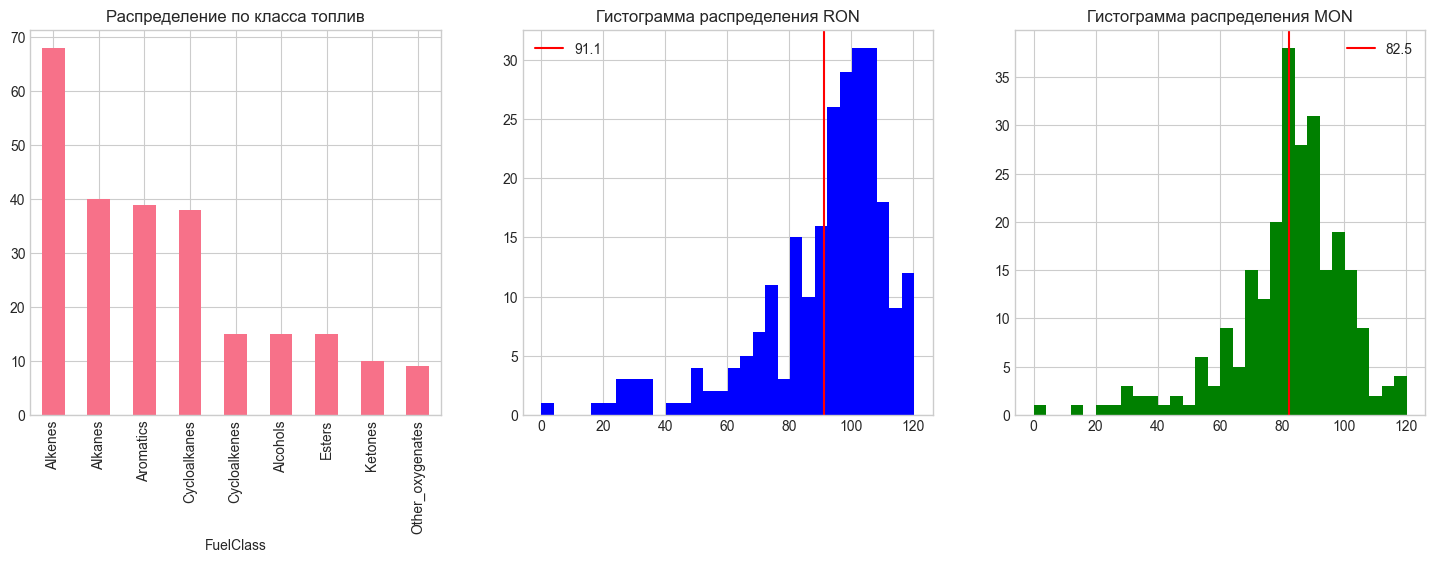

In [5]:
# YOUR CODE HERE
fig, axes = plt.subplots(1,3,figsize=(18,5))

df_clean["FuelClass"].value_counts().plot.bar(ax=axes[0])
axes[0].set_title("Распределение по класса топлив")
axes[1].hist(df_clean["RON"], bins=30, color="blue")
axes[1].axvline(df_clean["RON"].mean(), color="red", label= f"{df_clean["RON"].mean():.1f}")
axes[1].set_title("Гистограмма распределения RON")
axes[1].legend()

axes[2].hist(df_clean["MON"], bins=30, color="green")
axes[2].axvline(df_clean["MON"].mean(), color="red", label= f"{df_clean["MON"].mean():.1f}")
axes[2].set_title("Гистограмма распределения MON")
axes[2].legend()

### Задание 2: RON vs MON

Постройте scatter plot RON vs MON, раскрашенный по `FuelClass`.
Добавьте диагональную линию RON = MON для наглядности.

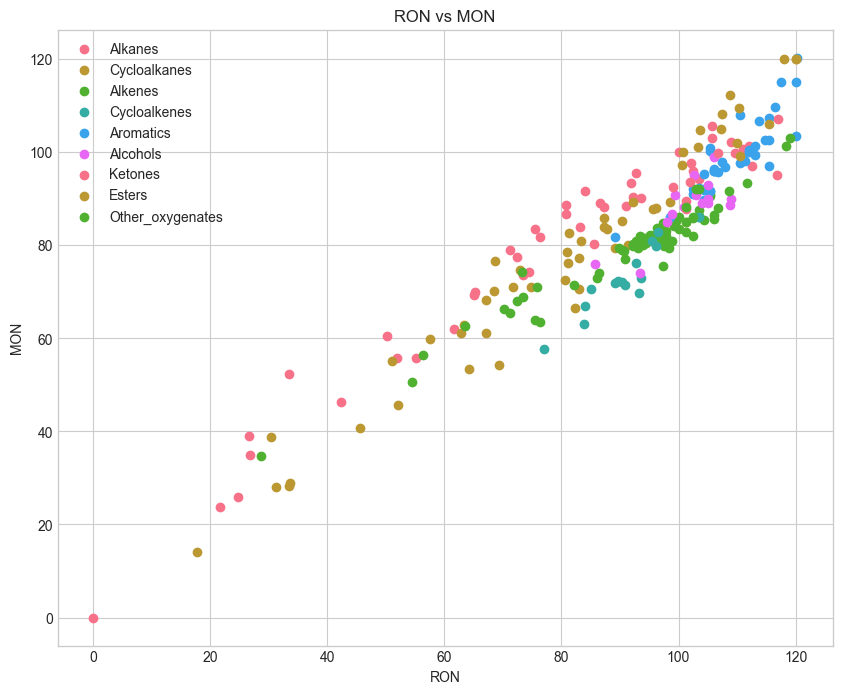

In [6]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10,8))
for f_c in df_clean["FuelClass"].unique():
    subset = df_clean[df_clean["FuelClass"] == f_c]
    ax.scatter(subset["RON"], subset["MON"], label=f_c)

ax.set_xlabel("RON")
ax.set_ylabel("MON")
ax.set_title("RON vs MON")
ax.legend()
plt.show()

### Задание 3: Boxplot по классам

Постройте boxplot RON и MON по классам топлив (отсортируйте по медиане RON).

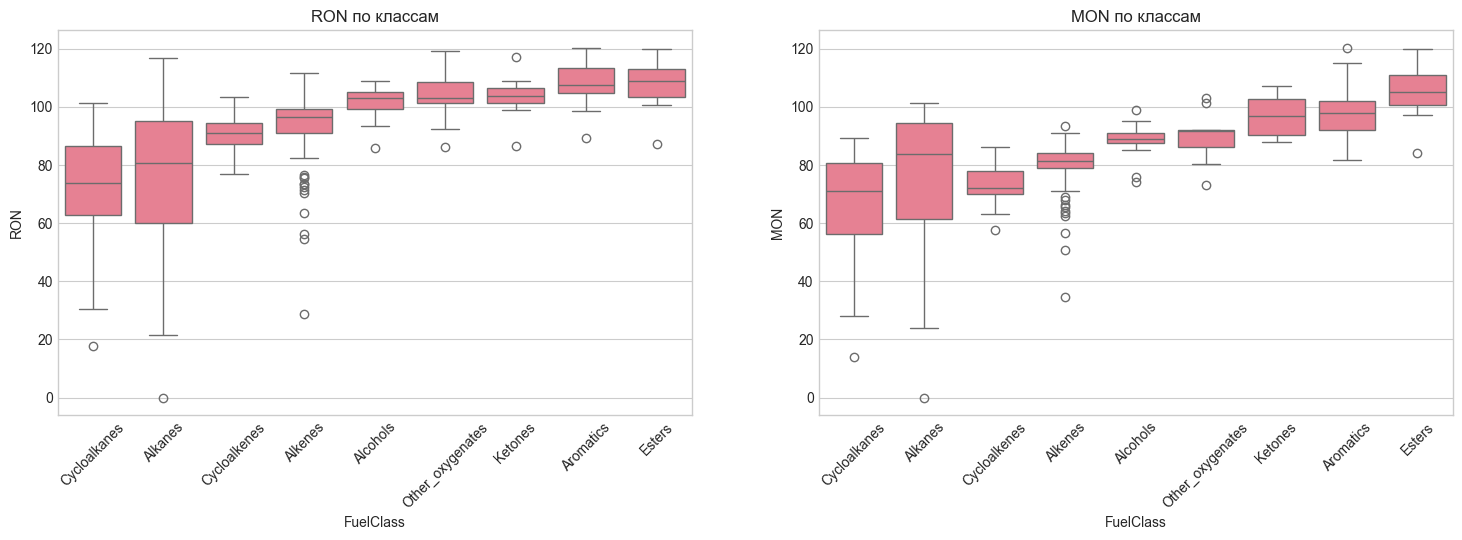

In [7]:
# YOUR CODE HERE
fig, axes = plt.subplots(1,2,figsize=(18,5))

order = df_clean.groupby("FuelClass")["RON"].median().sort_values().index

sns.boxplot(data=df_clean, x="FuelClass", y="RON", order=order, ax=axes[0])
axes[0].set_title("RON по классам")
axes[0].tick_params(axis= "x", rotation=45)

sns.boxplot(data=df_clean, x="FuelClass", y="MON", order=order, ax=axes[1])
axes[1].set_title("MON по классам")
axes[1].tick_params(axis= "x", rotation=45)

plt.show()

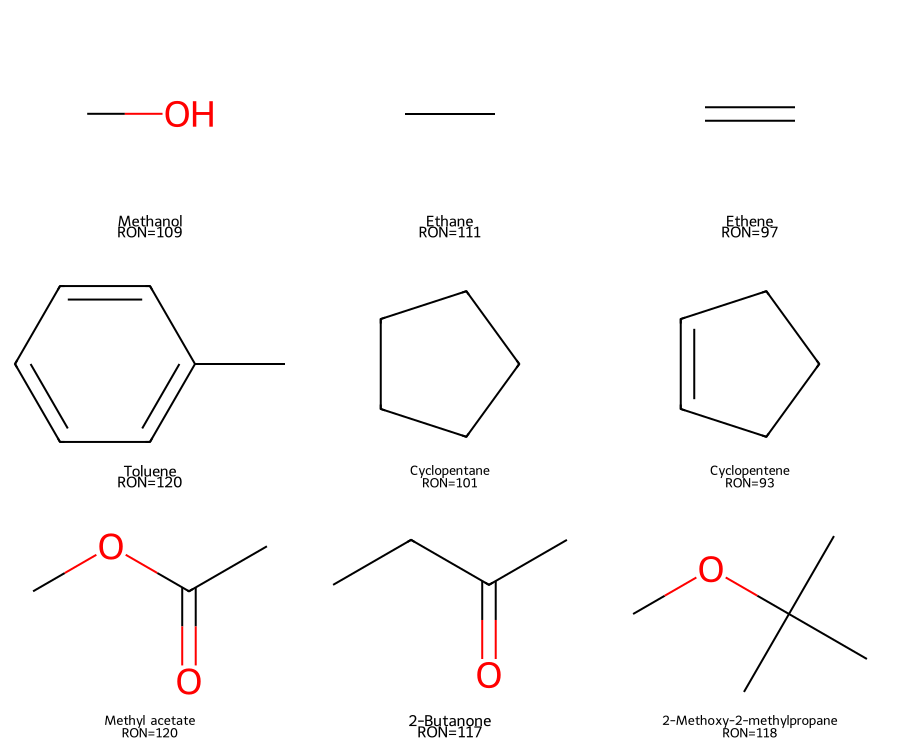

In [8]:
# Визуализация молекул из разных классов
samples = df_clean.groupby("FuelClass").first().reset_index()
mols = [Chem.MolFromSmiles(s) for s in samples["Smiles"]]
legends = [f"{row['Name']}\nRON={row['RON']:.0f}" for _, row in samples.iterrows()]

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 250), legends=legends)
img

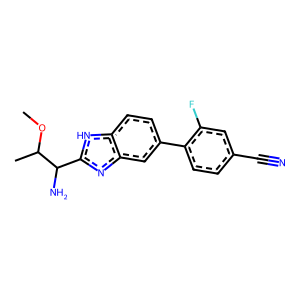

In [9]:
from IPython.display import display, SVG
smiles = "COC(C)C(N)c1nc2cc(-c3ccc(C#N)cc3F)ccc2[nH]1" 

mol = Chem.MolFromSmiles(smiles)
mol_kek = Chem.Mol(mol)
#Chem.Kekulize(mol_kek, clearAromaticFlags=True)
img = Draw.MolToImage(mol_kek, kekulize=False)
img

## 3. Построение молекулярных дескрипторов с RDKit

### Подходы к описанию молекул:

| Тип дескриптора | Описание | Пример |
|:---|:---|:---|
| **2D дескрипторы** | Физико-химические свойства | MolWt, LogP, TPSA, HBA/HBD |
| **Фингерпринты** | Бинарное представление субструктур | Morgan (ECFP), MACCS, RDKit FP |
| **3D дескрипторы** | Геометрия молекулы | Asphericity, Eccentricity |
| **Graph-based** | GNN на молекулярном графе | GCN, MPNN, AttentiveFP |

### Задание 4: Вычисление 2D дескрипторов

Реализуйте функцию `compute_rdkit_2d_descriptors(smiles_list)`, которая:
- Принимает список SMILES
- Для каждого SMILES создает `Chem.MolFromSmiles(smi)` и вычисляет дескрипторы через `Descriptors`
- Возвращает `pd.DataFrame`

Используйте дескрипторы: `MolWt`, `MolLogP`, `TPSA`, `NumHAcceptors`, `NumHDonors`, `NumRotatableBonds`,
`NumAromaticRings`, `NumAliphaticRings`, `RingCount`, `FractionCSP3`, `HeavyAtomCount` и другие на ваш выбор.

Подсказка: `getattr(Descriptors, name)` возвращает функцию-дескриптор.

In [10]:
from model_utils import (
    ALL_RDKIT_DESCRIPTOR_NAMES,
    compute_maccs_keys as _compute_maccs_keys,
    compute_morgan_fingerprints as _compute_morgan_fingerprints,
    compute_rdkit_2d_descriptors as _compute_rdkit_2d_descriptors,
)


def compute_rdkit_2d_descriptors(smiles_list: list[str]) -> pd.DataFrame:
    return _compute_rdkit_2d_descriptors(
        smiles_list,
        descriptor_names=ALL_RDKIT_DESCRIPTOR_NAMES,
    )


def comp_fingerprints(
    smiles_list: list[str],
    radius: int = 2,
    n_bits: int = 1024,
) -> pd.DataFrame:
    return _compute_morgan_fingerprints(smiles_list, radius=radius, n_bits=n_bits)


def comp_maccs_keys(smiles_list: list[str]) -> pd.DataFrame:
    return _compute_maccs_keys(smiles_list)


In [11]:
smiles = df_clean["Smiles"].tolist()

desc_2d = compute_rdkit_2d_descriptors(smiles)
morgan = comp_fingerprints(smiles)
maccs = comp_maccs_keys(smiles)
df_all = pd.concat([df_clean, desc_2d, morgan, maccs], axis=1)

df_all

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,Furan,Other_oxygenates,O1C=CC=C1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,0
245,2-Methylfuran,Other_oxygenates,CC1=CC=CO1,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,1,0
246,2_5-Dimethylfuran,Other_oxygenates,CC1=CC=C(C)O1,2,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,1,0
247,Anisole,Other_oxygenates,COC1=CC=CC=C1,1,0,0,0,0,0,0,...,1,0,0,1,0,1,1,1,1,0


### Задание 7: Вычислите дескрипторы и объедините

Вызовите все три функции для `df_clean["Smiles"]` и объедините результаты 2D + Morgan через `pd.concat`.

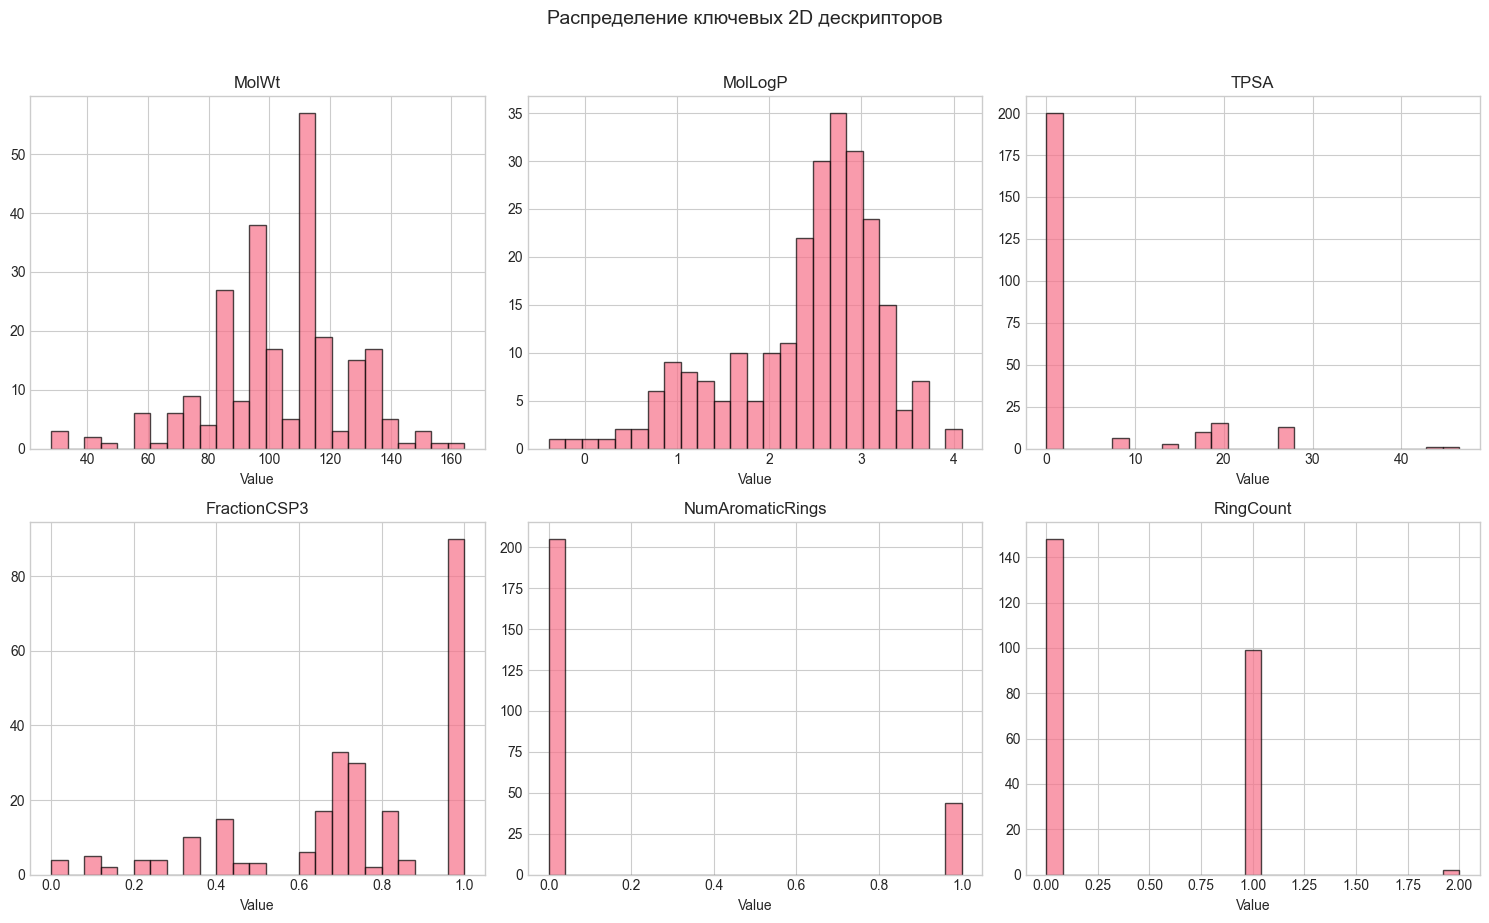

In [12]:
# Посмотрим на распределение нескольких ключевых дескрипторов
key_descriptors = ["MolWt", "MolLogP", "TPSA", "FractionCSP3", "NumAromaticRings", "RingCount"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, desc in zip(axes.flatten(), key_descriptors):
    ax.hist(desc_2d[desc].dropna(), bins=25, edgecolor="black", alpha=0.7)
    ax.set_title(desc)
    ax.set_xlabel("Value")

plt.suptitle("Распределение ключевых 2D дескрипторов", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Задание 8: Корреляция дескрипторов с целевыми переменными

Вычислите корреляцию Пирсона 2D-дескрипторов с RON и MON.
Постройте два горизонтальных барплота (`.plot.barh()`).

Подсказка: `desc_2d.corrwith(pd.Series(y_ron))`

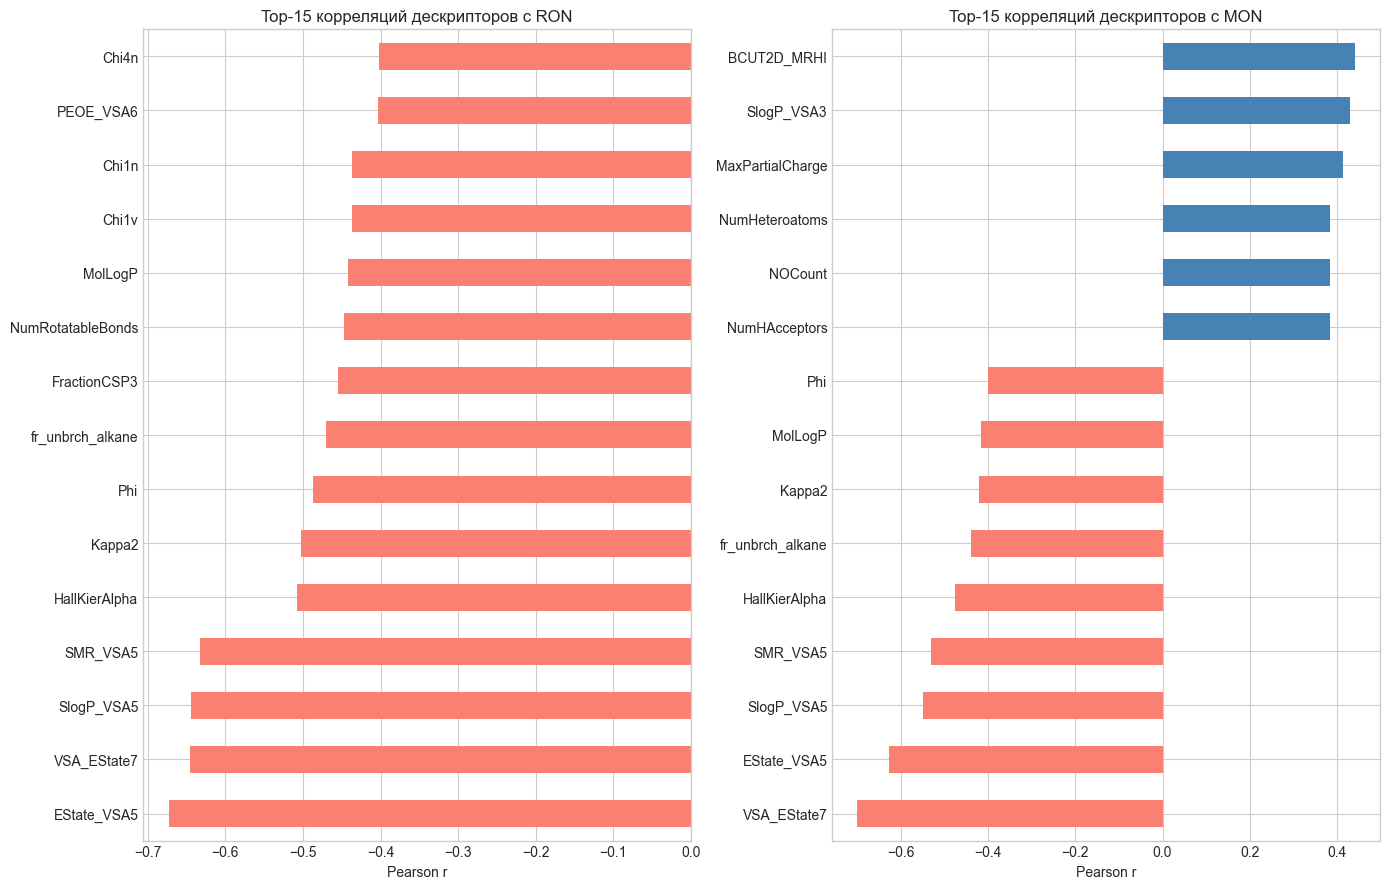

In [13]:
y_ron = df_clean["RON"].values
y_mon = df_clean["MON"].values

corr_ron = desc_2d.corrwith(pd.Series(y_ron)).dropna()
corr_mon = desc_2d.corrwith(pd.Series(y_mon)).dropna()

plot_ron = corr_ron.loc[corr_ron.abs().sort_values(ascending=False).head(15).index].sort_values()
plot_mon = corr_mon.loc[corr_mon.abs().sort_values(ascending=False).head(15).index].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 9))
plot_ron.plot.barh(ax=axes[0], color=["steelblue" if v > 0 else "salmon" for v in plot_ron])
plot_mon.plot.barh(ax=axes[1], color=["steelblue" if v > 0 else "salmon" for v in plot_mon])

axes[0].set_title("Top-15 корреляций дескрипторов с RON")
axes[1].set_title("Top-15 корреляций дескрипторов с MON")
axes[0].set_xlabel("Pearson r")
axes[1].set_xlabel("Pearson r")
plt.tight_layout()
plt.show()


## 4. Отбор признаков (Feature Selection)

При большом числе дескрипторов (особенно фингерпринтов) необходимо:

1. **Удалить константные/низковариативные** признаки
2. **Удалить сильно коррелированные** признаки (мультиколлинеарность)
3. **Отобрать наиболее информативные** признаки (mutual information, importance)

### Задание 9: Реализуйте функции отбора признаков

Реализуйте три функции:

1. `remove_low_variance(X, threshold)` -- используйте `VarianceThreshold` из sklearn
2. `remove_correlated(X, threshold)` -- удалите один из пары признаков с корреляцией > threshold
3. `select_by_mutual_info(X, y, n_features)` -- отберите top-N по `mutual_info_regression`

In [14]:
from model_utils import (
    remove_correlated,
    remove_low_variance,
    select_by_mutual_info as _select_by_mutual_info,
)


def select_by_mutual_info(
    X: pd.DataFrame,
    y: np.ndarray,
    n_features: int = 50,
) -> pd.DataFrame:
    selected, ranking = _select_by_mutual_info(X, y, n_features=n_features)

    fig, ax = plt.subplots(figsize=(10, 6))
    ranking.head(20).sort_values().plot.barh(ax=ax, color="teal")
    ax.set_title("Top-20 признаков по mutual information")
    ax.set_xlabel("Mutual information")
    plt.tight_layout()
    plt.show()

    return selected


In [15]:
df_all

,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165,maccs_166
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,Furan,Other_oxygenates,O1C=CC=C1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,0
245,2-Methylfuran,Other_oxygenates,CC1=CC=CO1,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,1,0
246,2_5-Dimethylfuran,Other_oxygenates,CC1=CC=C(C)O1,2,0,0,0,0,0,0,...,0,0,0,1,0,1,0,1,1,0
247,Anisole,Other_oxygenates,COC1=CC=CC=C1,1,0,0,0,0,0,0,...,1,0,0,1,0,1,1,1,1,0


### Задание 10: Примените пайплайн отбора признаков

Последовательно примените: `remove_low_variance` -> `remove_correlated` -> `select_by_mutual_info`.

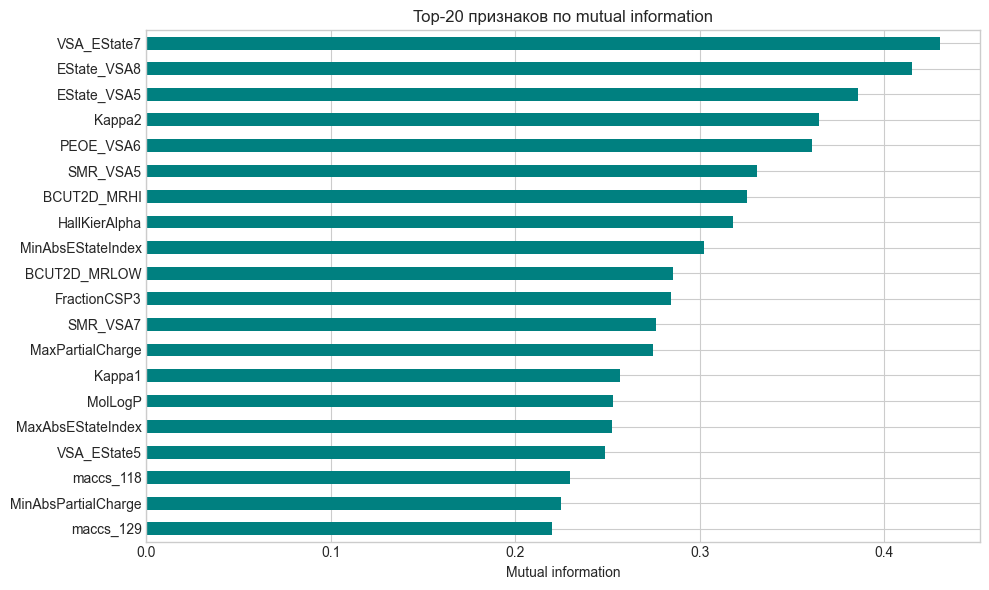

До отбора: 404 признаков
После low variance: 204
После correlation filter: 133
После mutual information: 80


In [16]:
manual_numeric = df_clean.drop(
    columns=["Name", "FuelClass", "Smiles", "RON", "MON", "OS"],
    errors="ignore",
)
X_all_filled = pd.concat([manual_numeric, desc_2d, maccs], axis=1).fillna(0)

X_var = remove_low_variance(X_all_filled, threshold=0.0)
X_cor = remove_correlated(X_var, threshold=0.95)
X_selected = select_by_mutual_info(X_cor, y_ron, n_features=80)

print(f"До отбора: {X_all_filled.shape[1]} признаков")
print(f"После low variance: {X_var.shape[1]}")
print(f"После correlation filter: {X_cor.shape[1]}")
print(f"После mutual information: {X_selected.shape[1]}")


In [17]:
feature_selection_summary = pd.DataFrame(
    {
        "Stage": [
            "Raw hybrid features",
            "After low variance",
            "After correlation filter",
            "After mutual information",
        ],
        "n_features": [
            X_all_filled.shape[1],
            X_var.shape[1],
            X_cor.shape[1],
            X_selected.shape[1],
        ],
    }
)

display(feature_selection_summary)
display(X_selected.head())


,Stage,n_features
0,Raw hybrid features,404
1,After low variance,204
2,After correlation filter,133
3,After mutual information,80


,VSA_EState7,EState_VSA8,EState_VSA5,Kappa2,PEOE_VSA6,SMR_VSA5,BCUT2D_MRHI,HallKierAlpha,MinAbsEStateIndex,BCUT2D_MRLOW,...,EState_VSA10,fr_ether,DD,PEOE_VSA2,BCUT2D_MWLOW,EState_VSA7,T*,fr_aryl_methyl,EState_VSA9,Dbc
0,0.000000,0.000000,0.000000,0.0,13.847474,13.847474,3.503000,0.0,2.000000,1.503000,...,0.0,0,0,0.0,11.011000,13.847474,0,0,0.0,0
1,1.250000,13.847474,6.420822,2.0,20.268296,20.268296,3.917714,0.0,1.250000,1.089286,...,0.0,0,0,0.0,10.597286,0.000000,0,0,0.0,0
2,2.638889,13.847474,12.841643,3.0,26.689118,26.689118,4.122205,0.0,1.319444,0.885584,...,0.0,0,0,0.0,10.393584,0.000000,0,0,0.0,0
3,4.076389,13.847474,19.262465,4.0,33.109939,33.109939,4.236962,0.0,1.343750,0.771705,...,0.0,0,0,0.0,10.279705,0.000000,0,0,0.0,0
4,5.536389,13.847474,25.683286,5.0,39.530761,39.530761,4.307622,0.0,1.355000,0.701864,...,0.0,0,0,0.0,10.209864,0.000000,0,0,0.0,0


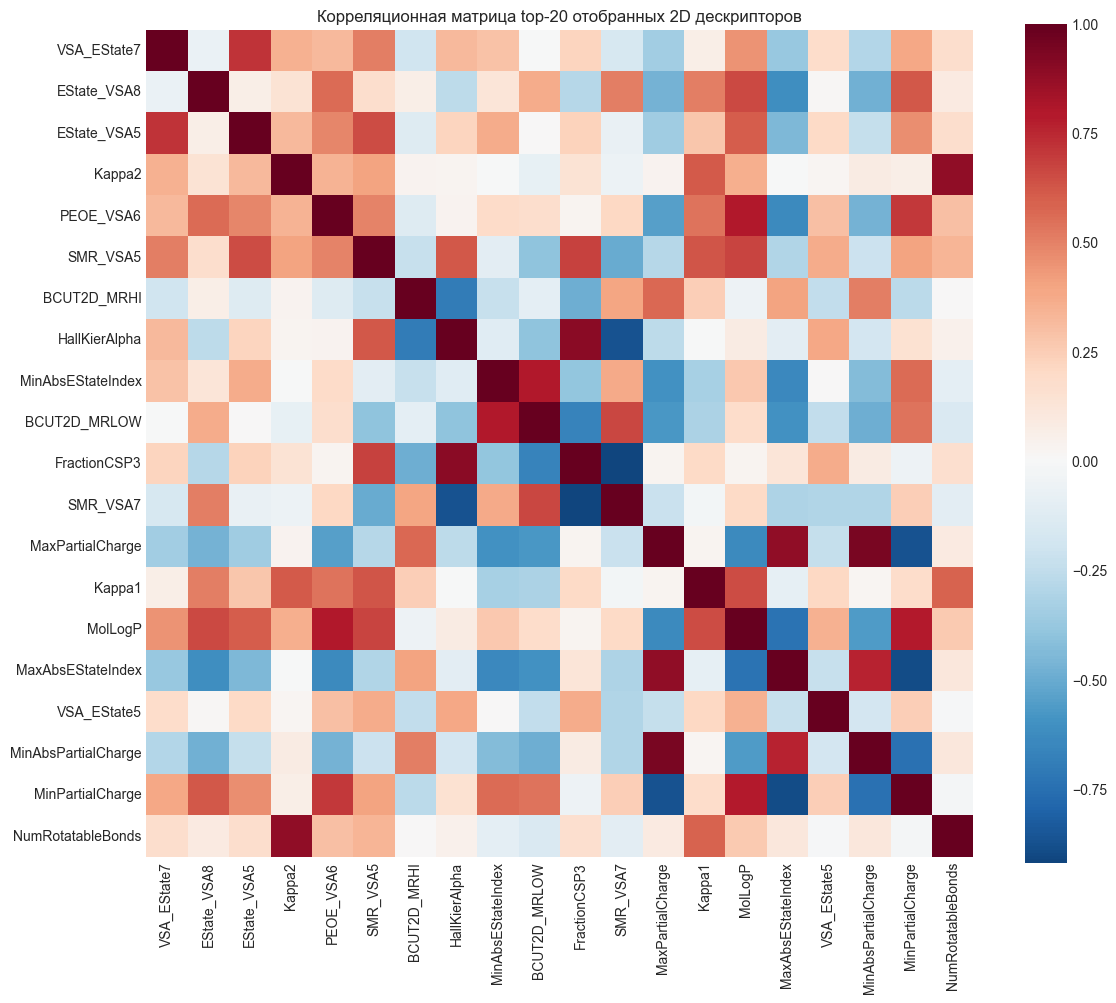

In [18]:
desc_2d_selected = [c for c in X_selected.columns if c in desc_2d.columns][:20]
if len(desc_2d_selected) > 2:
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        X_selected[desc_2d_selected].corr(),
        annot=False,
        cmap="RdBu_r",
        center=0,
        square=True,
        ax=ax,
    )
    ax.set_title("Корреляционная матрица top-20 отобранных 2D дескрипторов")
    plt.tight_layout()
    plt.show()


## 5. Обучение моделей

Сравним несколько подходов:
- **Linear Regression** (baseline)
- **Random Forest**
- **Gradient Boosting**
- **CatBoost**

### Задание 11: Разделение данных и функция оценки

1. Разделите данные на train/test (`train_test_split`, `test_size=0.2`, `random_state=42`)
2. Примените `StandardScaler` к train и test
3. Реализуйте функцию `evaluate_model(model, X_train, X_test, y_train, y_test, name)`,
   которая обучает модель, предсказывает и возвращает dict с MAE, RMSE, R2

In [19]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from model_utils import (
    ALL_RDKIT_DESCRIPTOR_NAMES,
    build_baseline_models,
    build_train_test_features,
    evaluate_model as evaluate_model_helper,
)


def evaluate_model(model, X_train, X_test, y_train, y_test, name: str) -> dict:
    return evaluate_model_helper(model, X_train, X_test, y_train, y_test, name)


df_model = df.dropna(subset=["RON"]).reset_index(drop=True).copy()
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
)

feature_bundle = build_train_test_features(
    train_df=train_df,
    test_df=test_df,
    target="RON",
    include_manual=True,
    include_fuel_class=True,
    include_rdkit=True,
    rdkit_descriptor_names=ALL_RDKIT_DESCRIPTOR_NAMES,
    rdkit_top_k=113,
    include_maccs=True,
    maccs_top_k=24,
    include_morgan=False,
    variance_threshold=0.0,
    correlation_threshold=0.9340499834393866,
)

X_train = feature_bundle.X_train
y_train = feature_bundle.y_train
X_test = feature_bundle.X_test
y_test = feature_bundle.y_test
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Модельный датасет: {len(df_model)} строк с известным RON")
feature_bundle.feature_summary


Модельный датасет: 256 строк с известным RON


{'manual': 21, 'rdkit': 79, 'maccs': 24, 'total': 124}

### Задание 12: Обучите и сравните модели

Создайте словарь моделей и обучите каждую:
- Linear Regression
- Ridge (alpha=1)
- Random Forest (n_estimators=200, max_depth=10)
- Gradient Boosting (n_estimators=200, learning_rate=0.1, max_depth=5)
- CatBoost (iterations=500, learning_rate=0.05, depth=6, verbose=0)

Учтите, что линейные модели требуют масштабирования (`X_train_scaled`), а деревья -- нет.

In [20]:
models = build_baseline_models(X_train, random_state=42)

baseline_results = []
fitted_baseline_models = {}
for name, model in models.items():
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    baseline_results.append(result)
    fitted_baseline_models[name] = model

baseline_results_df = pd.DataFrame(baseline_results).sort_values(["mae", "rmse"]).reset_index(drop=True)
display(baseline_results_df.style.format({"mae": "{:.3f}", "rmse": "{:.3f}", "r2": "{:.3f}"}))

best_baseline_name = baseline_results_df.loc[0, "model"]
best_baseline_model = fitted_baseline_models[best_baseline_name]
best_baseline_pred = best_baseline_model.predict(X_test)
print(f"Лучший baseline: {best_baseline_name}")


,model,mae,rmse,r2
0,CatBoost,4.496,6.132,0.897
1,Gradient Boosting,5.266,7.090,0.862
2,Random Forest,5.718,7.760,0.834
3,Linear Regression,5.753,8.204,0.815
4,Ridge,6.806,8.686,0.792


Лучший baseline: CatBoost


### Задание 13: Визуализация результатов

Постройте 3 графика:
1. Барплот MAE по моделям
2. Барплот R2 по моделям
3. Scatter Predicted vs True RON для лучшей модели

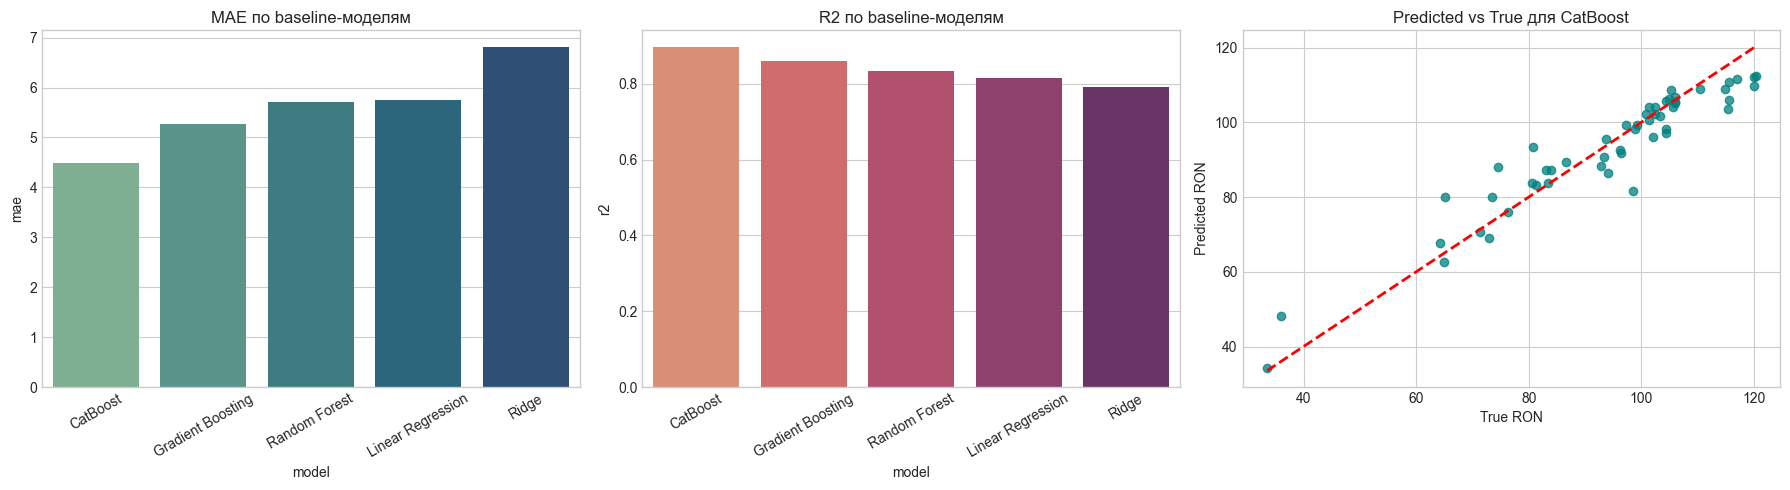

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=baseline_results_df, x="model", y="mae", ax=axes[0], palette="crest")
axes[0].set_title("MAE по baseline-моделям")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=baseline_results_df, x="model", y="r2", ax=axes[1], palette="flare")
axes[1].set_title("R2 по baseline-моделям")
axes[1].tick_params(axis="x", rotation=30)

axes[2].scatter(y_test, best_baseline_pred, alpha=0.75, color="teal")
line_min = min(y_test.min(), best_baseline_pred.min())
line_max = max(y_test.max(), best_baseline_pred.max())
axes[2].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)
axes[2].set_xlabel("True RON")
axes[2].set_ylabel("Predicted RON")
axes[2].set_title(f"Predicted vs True для {best_baseline_name}")

plt.tight_layout()
plt.show()


### Задание 14: Feature Importance

Выведите и визуализируйте top-20 признаков по важности (`feature_importances_`) для CatBoost.

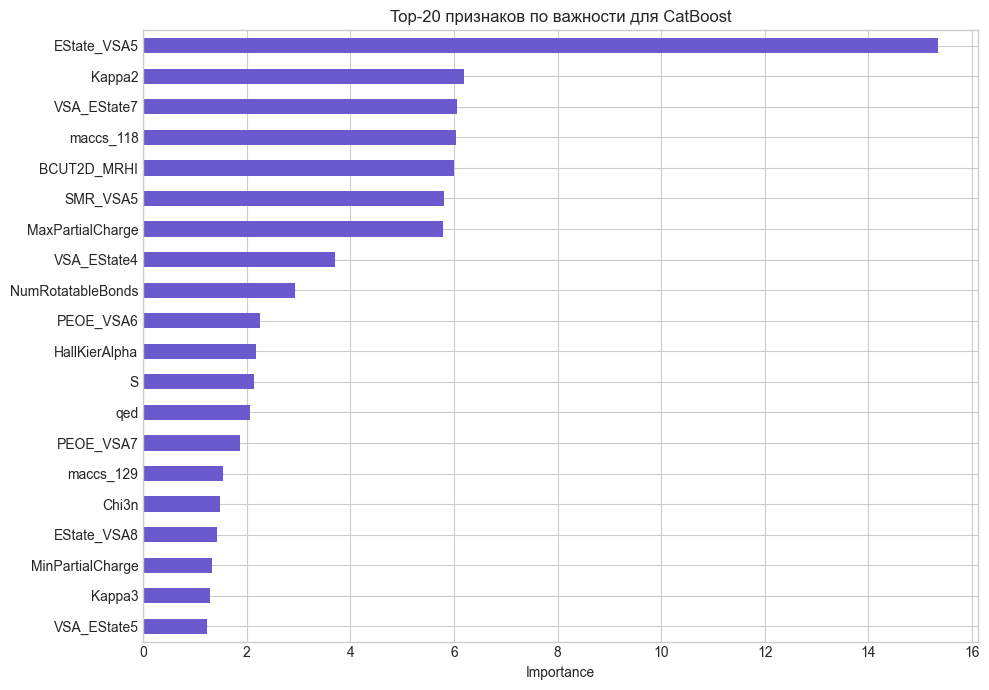

In [22]:
from model_utils import get_feature_names

catboost_model = fitted_baseline_models["CatBoost"]
catboost_feature_names = get_feature_names(catboost_model.named_steps["pre"])
catboost_feature_names = [
    name.replace("num__", "").replace("cat__encoder__", "")
    for name in catboost_feature_names
]

feature_importance = pd.Series(
    catboost_model.named_steps["model"].feature_importances_,
    index=catboost_feature_names,
).sort_values(ascending=False)

top_importance = feature_importance.head(20).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
top_importance.plot.barh(ax=ax, color="slateblue")
ax.set_title("Top-20 признаков по важности для CatBoost")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 6. Логирование экспериментов с MLflow

**MLflow** позволяет:
- Отслеживать параметры, метрики и артефакты экспериментов
- Сравнивать разные запуски
- Воспроизводить результаты

```
# Запуск UI после выполнения ячеек:
# mlflow ui --backend-store-uri mlruns
```

In [23]:
import mlflow
import mlflow.sklearn
import mlflow.catboost

# Настраиваем MLflow
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("RON_MON_prediction")

print("MLflow настроен. Experiment: RON_MON_prediction")

MLflow настроен. Experiment: RON_MON_prediction


### Задание 15: Логирование в MLflow

Для каждой модели создайте `mlflow.start_run()` и залогируйте:
- Параметры: `mlflow.log_param("model_type", name)`, n_features, target
- Метрики: `mlflow.log_metric("mae", mae)`, rmse, r2
- Модель: `mlflow.sklearn.log_model(model, "model")` или `mlflow.catboost.log_model(model, "model")`

In [24]:
for _, row in baseline_results_df.iterrows():
    name = row["model"]
    model = fitted_baseline_models[name]
    with mlflow.start_run(run_name=f"baseline_{name}"):
        mlflow.log_param("model_type", name)
        mlflow.log_param("target", "RON")
        mlflow.log_param("n_features", feature_bundle.feature_summary["total"])
        for block_name, block_size in feature_bundle.feature_summary.items():
            mlflow.log_param(f"features_{block_name}", block_size)
        mlflow.log_metric("mae", float(row["mae"]))
        mlflow.log_metric("rmse", float(row["rmse"]))
        mlflow.log_metric("r2", float(row["r2"]))
        mlflow.sklearn.log_model(model, artifact_path="model")

print(f"Сохранено baseline-запусков в MLflow: {len(baseline_results_df)}")


2026/04/24 00:58:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/24 00:58:29 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/mac/Desktop/chem_ml/materials/RON_MON


2026/04/24 00:58:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/24 00:58:29 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/mac/Desktop/chem_ml/materials/RON_MON


2026/04/24 00:58:29 INFO mlflow.utils.environment: Detected uv project at /Users/mac/Desktop/chem_ml/materials/RON_MON. Attempting to export requirements via 'uv export'.


...

2026/04/24 00:58:30 INFO mlflow.utils.environment: Detected uv project at /Users/mac/Desktop/chem_ml/materials/RON_MON. Attempting to export requirements via 'uv export'.


2026/04/24 00:58:30 INFO mlflow.utils.uv_utils: Exported 180 dependencies via uv


2026/04/24 00:58:30 INFO mlflow.utils.environment: Successfully exported 180 requirements from uv project. Skipping package capture based inference.


2026/04/24 00:58:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Сохранено baseline-запусков в MLflow: 5


## 7. Конфигурация пайплайна с Hydra

**Hydra** позволяет:
- Выносить все параметры в YAML-конфиги
- Запускать эксперименты с разными конфигурациями из CLI
- Делать multirun (sweep) по параметрам

Конфиг `configs/config.yaml` уже создан. Посмотрим, как его использовать:

In [25]:
# Загрузка конфига Hydra в ноутбуке
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import os

config_dir = os.path.join(os.getcwd(), "configs")

with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg))

data:
  path: data.csv
  target: RON
  test_size: 0.2
  random_state: 42
features:
  include_manual: true
  include_fuel_class: true
  include_rdkit: true
  rdkit_descriptor_set: all
  rdkit_top_k: 80
  include_maccs: true
  maccs_top_k: 16
  include_morgan: false
  morgan_radius: 2
  morgan_bits: 1024
  morgan_top_k: 128
  variance_threshold: 0.0
  correlation_threshold: 0.95
model:
  name: gaussian_process_rbf
  catboost:
    iterations: 800
    learning_rate: 0.04
    depth: 6
    l2_leaf_reg: 4.0
    subsample: 0.9
    random_strength: 0.5
    bagging_temperature: 0.0
  gaussian_process:
    kernel_name: rbf
    pca_components: 25
    alpha: 0.0001
    n_restarts_optimizer: 1
mlflow:
  tracking_uri: mlruns
  experiment_name: RON_MON_prediction



In [26]:
# Пример использования конфига
print(f"Target: {cfg.data.target}")
print(f"Test size: {cfg.data.test_size}")
print(f"Model: {cfg.model.name}")
print(f"CatBoost iterations: {cfg.model.catboost.iterations}")
print(f"RDKit top-k: {cfg.features.rdkit_top_k}")
print(f"Use MACCS: {cfg.features.include_maccs}")

print("\n--- Пайплайн можно запускать из CLI: ---")
print("python pipeline.py")
print("python pipeline.py model.name=gaussian_process_rbf")
print("python pipeline.py model.name=catboost features.rdkit_top_k=113 features.maccs_top_k=24")


Target: RON
Test size: 0.2
Model: gaussian_process_rbf
CatBoost iterations: 800
RDKit top-k: 80
Use MACCS: True

--- Пайплайн можно запускать из CLI: ---
python pipeline.py
python pipeline.py model.name=gaussian_process_rbf
python pipeline.py model.name=catboost features.rdkit_top_k=113 features.maccs_top_k=24


## 8. Подбор гиперпараметров с Optuna

**Optuna** -- фреймворк для автоматического подбора гиперпараметров:
- Алгоритм TPE (Tree-structured Parzen Estimator)
- Pruning неперспективных trial-ов
- Визуализация пространства поиска

### Задание 16: Optuna -- целевая функция

Реализуйте `objective(trial)` для оптимизации CatBoost:

Используйте `trial.suggest_*` для параметров:
- `iterations`: int, 100-1000
- `learning_rate`: float, 0.01-0.3, log scale
- `depth`: int, 3-10
- `l2_leaf_reg`: float, 0.01-10, log scale
- `min_data_in_leaf`: int, 1-30

Оцените через `cross_val_score` с `scoring="neg_mean_absolute_error"` и верните `-scores.mean()`.

Создайте study и запустите `study.optimize(objective, n_trials=30, timeout=120)`.

In [27]:
import optuna
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from model_utils import build_preprocessor

optuna.logging.set_verbosity(optuna.logging.WARNING)

seed_params = {
    "iterations": 800,
    "learning_rate": 0.04,
    "depth": 6,
    "l2_leaf_reg": 4.0,
    "subsample": 0.9,
    "random_strength": 0.5,
    "bagging_temperature": 0.0,
}


def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.06, log=True),
        "depth": trial.suggest_int("depth", 5, 7),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2.0, 6.0),
        "subsample": trial.suggest_float("subsample", 0.8, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 1.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "loss_function": "RMSE",
        "eval_metric": "MAE",
        "random_seed": 42,
        "verbose": False,
    }
    model = Pipeline(
        [
            ("pre", build_preprocessor(X_train)),
            ("model", CatBoostRegressor(**params)),
        ]
    )
    scores = -cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=1,
    )
    return scores.mean()


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.enqueue_trial(seed_params)
study.optimize(objective, n_trials=12, show_progress_bar=False)

print(f"Best CV MAE: {study.best_value:.3f}")
study.best_params


Best CV MAE: 5.323


{'iterations': 816,
 'learning_rate': 0.04191124366627289,
 'depth': 6,
 'l2_leaf_reg': 5.488994080416483,
 'subsample': 0.9303733101556357,
 'random_strength': 0.6902470735691453,
 'bagging_temperature': 0.015165720318569732}

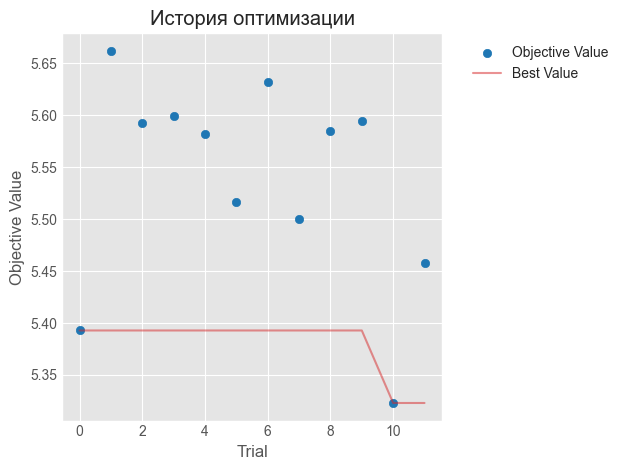

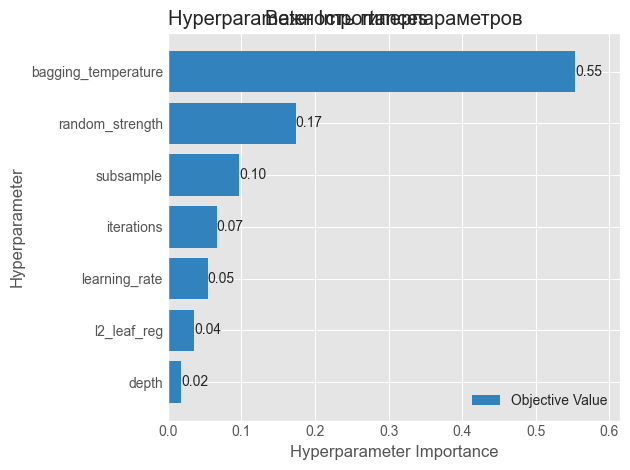

In [28]:
# Визуализация результатов Optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

ax = plot_optimization_history(study)
ax.set_title("История оптимизации")
plt.tight_layout()
plt.show()

ax = plot_param_importances(study)
ax.set_title("Важность гиперпараметров")
plt.tight_layout()
plt.show()


### Задание 17: Финальная модель

1. Обучите CatBoost с лучшими параметрами из `study.best_params`
2. Выведите MAE, RMSE, R2 на тестовой выборке
3. Залогируйте результат в MLflow (run_name="CatBoost_Optuna_best")

In [29]:
from model_utils import build_final_models, build_gaussian_process_model

final_models = build_final_models(
    X_train,
    catboost_params=study.best_params,
    random_state=42,
)

final_results = []
fitted_final_models = {}
for name, model in final_models.items():
    if name.startswith("Gaussian Process"):
        continue
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    final_results.append({**result, "feature_setup": "catboost_hybrid"})
    fitted_final_models[name] = model

kernel_feature_bundle = build_train_test_features(
    train_df=train_df,
    test_df=test_df,
    target="RON",
    include_manual=True,
    include_fuel_class=True,
    include_rdkit=True,
    rdkit_descriptor_names=ALL_RDKIT_DESCRIPTOR_NAMES,
    rdkit_top_k=80,
    include_maccs=True,
    maccs_top_k=16,
    include_morgan=False,
    variance_threshold=0.0,
    correlation_threshold=0.95,
)

gp_models = {
    "Gaussian Process RBF": build_gaussian_process_model(
        kernel_feature_bundle.X_train,
        kernel_name="rbf",
        pca_components=25,
        alpha=1e-4,
        n_restarts_optimizer=1,
        random_state=42,
    ),
    "Gaussian Process Matern": build_gaussian_process_model(
        kernel_feature_bundle.X_train,
        kernel_name="matern25",
        pca_components=25,
        alpha=1e-4,
        n_restarts_optimizer=1,
        random_state=42,
    ),
}
for name, model in gp_models.items():
    result = evaluate_model(
        model,
        kernel_feature_bundle.X_train,
        kernel_feature_bundle.X_test,
        kernel_feature_bundle.y_train,
        kernel_feature_bundle.y_test,
        name,
    )
    final_results.append({**result, "feature_setup": "kernel_friendly"})
    fitted_final_models[name] = model

final_results_df = pd.DataFrame(final_results).sort_values(["mae", "rmse"]).reset_index(drop=True)
display(final_results_df.style.format({"mae": "{:.3f}", "rmse": "{:.3f}", "r2": "{:.3f}"}))

catboost_optuna_model = fitted_final_models["CatBoost Optuna"]
catboost_optuna_pred = catboost_optuna_model.predict(X_test)
catboost_optuna_metrics = final_results_df.loc[
    final_results_df["model"] == "CatBoost Optuna"
].iloc[0]

best_final_name = final_results_df.loc[0, "model"]
best_final_model = fitted_final_models[best_final_name]
if best_final_name.startswith("Gaussian Process"):
    best_final_pred = best_final_model.predict(kernel_feature_bundle.X_test)
else:
    best_final_pred = best_final_model.predict(X_test)
print(f"Лучшая финальная модель: {best_final_name}")

with mlflow.start_run(run_name="CatBoost_Optuna_best"):
    mlflow.log_param("model_type", "CatBoost Optuna")
    for param_name, param_value in study.best_params.items():
        mlflow.log_param(param_name, param_value)
    mlflow.log_metric("mae", float(catboost_optuna_metrics["mae"]))
    mlflow.log_metric("rmse", float(catboost_optuna_metrics["rmse"]))
    mlflow.log_metric("r2", float(catboost_optuna_metrics["r2"]))
    mlflow.sklearn.log_model(catboost_optuna_model, artifact_path="model")

if best_final_name != "CatBoost Optuna":
    best_final_metrics = final_results_df.loc[final_results_df["model"] == best_final_name].iloc[0]
    with mlflow.start_run(run_name="Best_final_model"):
        mlflow.log_param("model_type", best_final_name)
        mlflow.log_param("feature_setup", best_final_metrics["feature_setup"])
        mlflow.log_metric("mae", float(best_final_metrics["mae"]))
        mlflow.log_metric("rmse", float(best_final_metrics["rmse"]))
        mlflow.log_metric("r2", float(best_final_metrics["r2"]))
        mlflow.sklearn.log_model(best_final_model, artifact_path="model")


,model,mae,rmse,r2,feature_setup
0,Gaussian Process RBF,3.920,4.873,0.935,kernel_friendly
1,Gaussian Process Matern,4.002,4.827,0.936,kernel_friendly
2,CatBoost Optuna,4.248,5.729,0.910,catboost_hybrid
3,Blend (CatBoost + GBR),4.277,5.767,0.909,catboost_hybrid
4,Blend (CatBoost + GBR + ET),4.444,5.934,0.903,catboost_hybrid
5,Gradient Boosting Strong,4.639,6.347,0.889,catboost_hybrid
6,Extra Trees Strong,5.737,7.748,0.835,catboost_hybrid


2026/04/24 00:59:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/24 00:59:27 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/mac/Desktop/chem_ml/materials/RON_MON


2026/04/24 00:59:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/24 00:59:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/mac/Desktop/chem_ml/materials/RON_MON


...

2026/04/24 00:59:28 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/mac/Desktop/chem_ml/materials/RON_MON


2026/04/24 00:59:28 INFO mlflow.utils.environment: Detected uv project at /Users/mac/Desktop/chem_ml/materials/RON_MON. Attempting to export requirements via 'uv export'.


2026/04/24 00:59:28 INFO mlflow.utils.uv_utils: Exported 180 dependencies via uv


2026/04/24 00:59:28 INFO mlflow.utils.environment: Successfully exported 180 requirements from uv project. Skipping package capture based inference.


2026/04/24 00:59:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


### Задание 18: Финальная визуализация

Постройте два графика:
1. Predicted vs True RON для лучшей модели
2. Анализ остатков (residuals vs predicted)

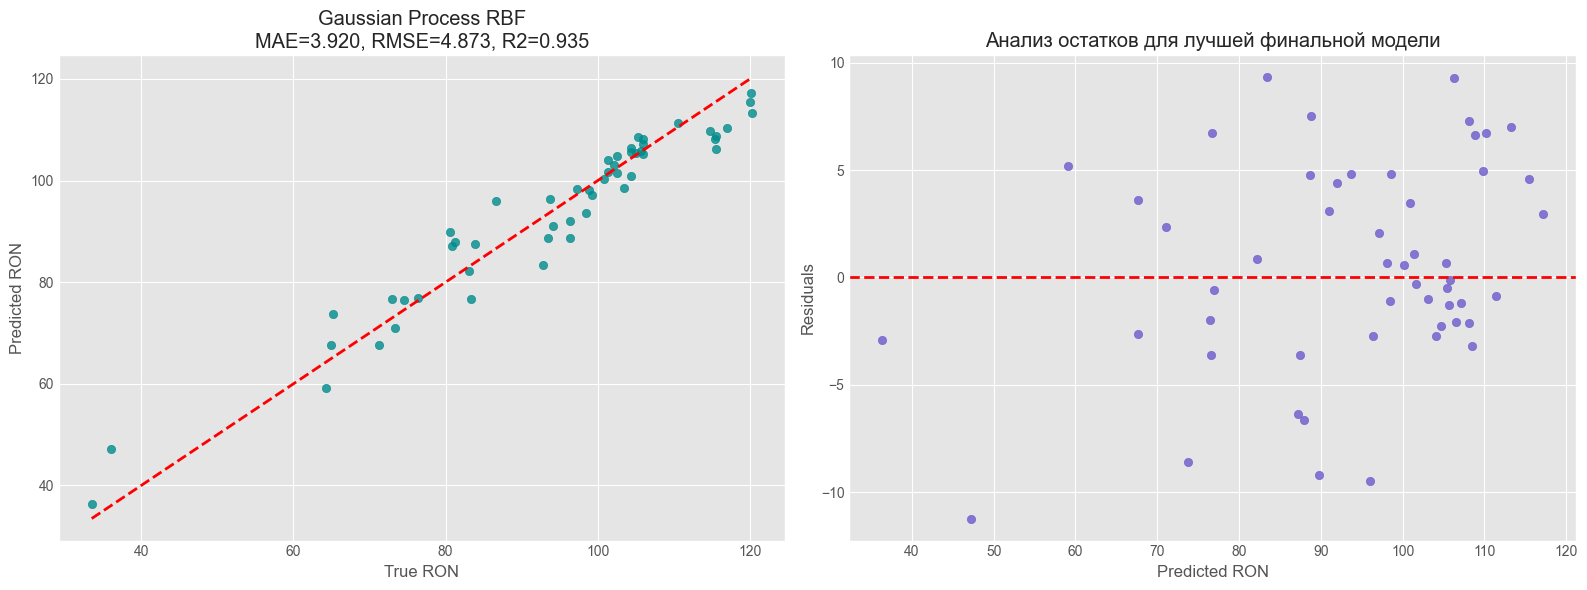

In [30]:
residuals = y_test - best_final_pred
best_metrics = final_results_df.loc[final_results_df["model"] == best_final_name].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, best_final_pred, alpha=0.8, color="darkcyan")
line_min = min(y_test.min(), best_final_pred.min())
line_max = max(y_test.max(), best_final_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)
axes[0].set_xlabel("True RON")
axes[0].set_ylabel("Predicted RON")
axes[0].set_title(
    f"{best_final_name}\nMAE={best_metrics['mae']:.3f}, RMSE={best_metrics['rmse']:.3f}, R2={best_metrics['r2']:.3f}"
)

axes[1].scatter(best_final_pred, residuals, alpha=0.8, color="slateblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicted RON")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Анализ остатков для лучшей финальной модели")

plt.tight_layout()
plt.show()


## 9. Итоговый пайплайн

Файл `pipeline.py` объединяет все шаги в единый пайплайн с Hydra-конфигурацией:

```bash
# Базовый запуск
python pipeline.py

# Предсказание MON вместо RON
python pipeline.py data.target=MON

# Другая модель
python pipeline.py model.name=random_forest

# Sweep по гиперпараметрам
python pipeline.py --multirun model.catboost.depth=4,6,8 model.catboost.learning_rate=0.01,0.05,0.1

# Просмотр результатов в MLflow
mlflow ui --backend-store-uri mlruns
```

### Что мы изучили:

1. **RDKit** -- вычисление 2D дескрипторов, Morgan/MACCS fingerprints
2. **Feature Selection** -- VarianceThreshold, корреляционный фильтр, Mutual Information
3. **Модели** -- от линейных до gradient boosting (CatBoost)
4. **MLflow** -- логирование параметров, метрик, моделей
5. **Hydra** -- управление конфигурацией пайплайна
6. **Optuna** -- автоматический подбор гиперпараметров

### Задания для самостоятельной работы

1. Обучите модель для предсказания **MON** вместо RON. Сравните качество.
2. Добавьте **MACCS fingerprints** к признакам и оцените влияние на качество.
3. Попробуйте использовать только **структурные дескрипторы из датасета** (P, S, T, ...) без RDKit-дескрипторов.
4. Реализуйте **кросс-валидацию с группами** (GroupKFold по FuelClass) -- как изменится качество?
5. Настройте Optuna для оптимизации **одновременно RON и MON** (multi-objective).